In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
print(f"Current Path: {os.getcwd()}")
print(f"Parent Path: {Path(os.getcwd()).parent}")

data_path = Path(os.getcwd()).parent / 'data' / 'processed' / 'cleaned_02_nav_history.csv'

if not data_path.exists():
    print(f"Still not found at: {data_path}")
else:
    df = pd.read_csv(data_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['scheme_name', 'date'])
    df = df.set_index('date').groupby('scheme_name').apply(
        lambda x: x.reindex(pd.date_range(start=x.index.min(), end=x.index.max(), freq='D')).ffill()
    ).reset_index(level=0, drop=True).reset_index().rename(columns={'index': 'date'})
    df['daily_return'] = df.groupby('scheme_name')['nav'].pct_change()

Current Path: c:\Users\User\Desktop\Internship Projects
Parent Path: c:\Users\User\Desktop
Still not found at: c:\Users\User\Desktop\data\processed\cleaned_02_nav_history.csv


In [3]:
data_path = Path.cwd() / 'data' / 'processed' / 'cleaned_02_nav_history.csv'
df = pd.read_csv(data_path)
print(df.columns.tolist())

['amfi_code', 'date', 'nav']


In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['amfi_code', 'date']) 

df = df.set_index('date').groupby('amfi_code').apply(
    lambda x: x.reindex(pd.date_range(start=x.index.min(), end=x.index.max(), freq='D')).ffill()
).reset_index(level=0, drop=True).reset_index().rename(columns={'index': 'date'})

df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()

C:\Users\User\AppData\Local\Temp\ipykernel_16924\689913952.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.set_index('date').groupby('amfi_code').apply(


In [5]:
def get_cagr(group, years):
    days = years * 252
    if len(group) >= days:
        final_nav = group['nav'].iloc[-1]
        initial_nav = group['nav'].iloc[-days]
        return (final_nav / initial_nav) ** (1 / years) - 1
    return np.nan

performance_metrics = df.groupby('amfi_code').apply(
    lambda x: pd.Series({
        'CAGR_1Y': get_cagr(x, 1),
        'CAGR_3Y': get_cagr(x, 3),
        'CAGR_5Y': get_cagr(x, 5)
    })
).reset_index()

print("Performance Metrics:")
print(performance_metrics.head())

Performance Metrics:
   amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y
0   100016.0 -0.043374 -0.017960  0.037204
1   100025.0  0.026913  0.041105  0.029228
2   100033.0  0.357242  0.244077  0.231056
3   101206.0  0.375166  0.223977  0.174277
4   101207.0 -0.091959 -0.055736  0.013231


C:\Users\User\AppData\Local\Temp\ipykernel_16924\3510264278.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  performance_metrics = df.groupby('amfi_code').apply(


In [6]:
risk_free_rate = 0.06 / 252

def calculate_risk_metrics(group):
    excess_return = group['daily_return'] - risk_free_rate
    sharpe = excess_return.mean() / excess_return.std() * np.sqrt(252)
    
    
    negative_returns = excess_return[excess_return < 0]
    sortino = excess_return.mean() / negative_returns.std() * np.sqrt(252)
    
    return pd.Series({'Sharpe_Ratio': sharpe, 'Sortino_Ratio': sortino})

risk_metrics = df.groupby('amfi_code').apply(calculate_risk_metrics).reset_index()

print("\nRisk Metrics:")
print(risk_metrics.head())


Risk Metrics:
   amfi_code  Sharpe_Ratio  Sortino_Ratio
0   100016.0     -0.280370      -0.411479
1   100025.0     -0.888610      -1.304810
2   100033.0      0.839461       1.230134
3   101206.0      0.757954       1.139529
4   101207.0      0.075540       0.109285


C:\Users\User\AppData\Local\Temp\ipykernel_16924\1020101988.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  risk_metrics = df.groupby('amfi_code').apply(calculate_risk_metrics).reset_index()


In [7]:
final_report = pd.merge(performance_metrics, risk_metrics, on='amfi_code')

print("Final Investment Report Card:")
print(final_report.head())



Final Investment Report Card:
   amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y  Sharpe_Ratio  Sortino_Ratio
0   100016.0 -0.043374 -0.017960  0.037204     -0.280370      -0.411479
1   100025.0  0.026913  0.041105  0.029228     -0.888610      -1.304810
2   100033.0  0.357242  0.244077  0.231056      0.839461       1.230134
3   101206.0  0.375166  0.223977  0.174277      0.757954       1.139529
4   101207.0 -0.091959 -0.055736  0.013231      0.075540       0.109285


In [8]:
top_funds = final_report.sort_values(by='Sharpe_Ratio', ascending=False).head(5)
print("Top 5 Funds by Sharpe Ratio:")
print(top_funds)

Top 5 Funds by Sharpe Ratio:
    amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y  Sharpe_Ratio  Sortino_Ratio
34   148567.0  0.044589  0.251275  0.183233      1.109804       1.614957
30   120843.0  0.250570  0.216700  0.229281      1.002723       1.543095
36   148569.0  0.402869  0.208904  0.188286      0.952459       1.437144
25   120505.0  0.274833  0.157223  0.181059      0.913872       1.366273
19   119551.0  0.328667  0.285602  0.195129      0.903945       1.367474


In [9]:
final_report.to_csv('final_fund_performance_report.csv', index=False)
print("Report 'final_fund_performance_report.csv'")

Report 'final_fund_performance_report.csv'


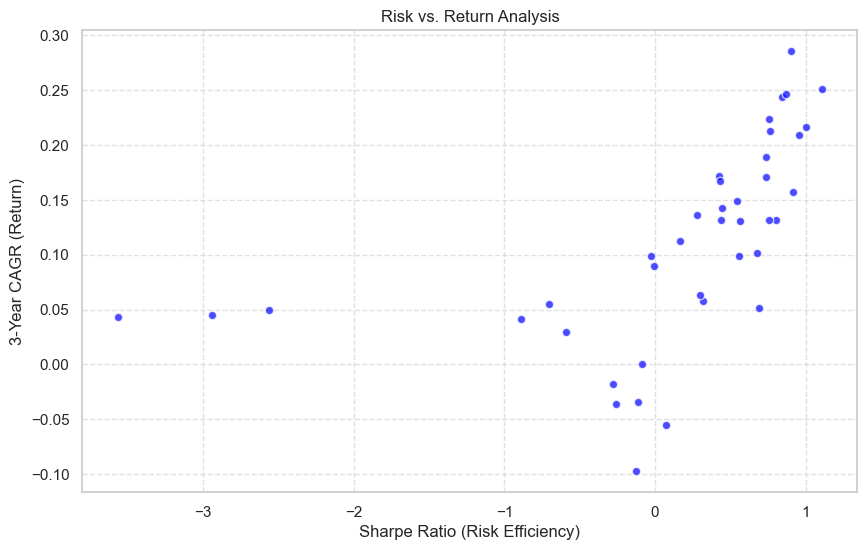

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(final_report['Sharpe_Ratio'], final_report['CAGR_3Y'], alpha=0.7, c='blue', edgecolors='white')
plt.xlabel('Sharpe Ratio (Risk Efficiency)')
plt.ylabel('3-Year CAGR (Return)')
plt.title('Risk vs. Return Analysis')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

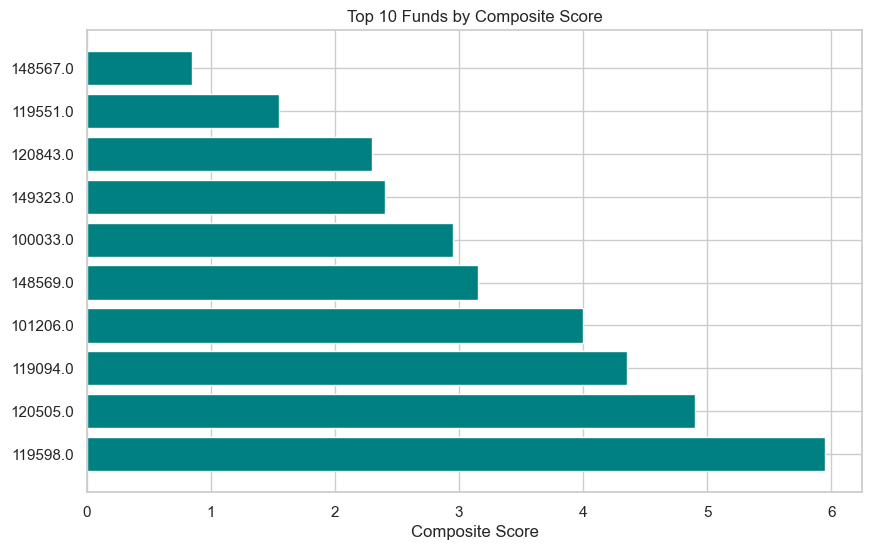

In [11]:
final_report['rank_3yr'] = final_report['CAGR_3Y'].rank(ascending=False)
final_report['rank_sharpe'] = final_report['Sharpe_Ratio'].rank(ascending=False)

final_report['Score'] = (0.30 * final_report['rank_3yr']) + (0.25 * final_report['rank_sharpe'])

import matplotlib.pyplot as plt

top_10 = final_report.sort_values(by='Score', ascending=True).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10['amfi_code'].astype(str), top_10['Score'], color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 Funds by Composite Score')
plt.xlabel('Composite Score')
plt.show()

In [12]:
from scipy import stats

df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()

bench_data = df[df['amfi_code'] == 'NIFTY_100'].set_index('date')['daily_return'].rename('bench_ret')
df = df.merge(bench_data, on='date', how='left')

def calc_metrics(group):
    data = group.dropna(subset=['daily_return', 'bench_ret'])
    if len(data) < 30:
        return pd.Series({'Alpha': np.nan, 'Beta': np.nan})
    slope, intercept, _, _, _ = stats.linregress(data['bench_ret'], data['daily_return'])
    return pd.Series({'Alpha': intercept * 252, 'Beta': slope})

alpha_beta_results = df.groupby('amfi_code').apply(calc_metrics).reset_index()

final_report = final_report.merge(alpha_beta_results, on='amfi_code')

C:\Users\User\AppData\Local\Temp\ipykernel_16924\4219524569.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  alpha_beta_results = df.groupby('amfi_code').apply(calc_metrics).reset_index()


In [13]:
check_data = df.groupby('amfi_code').apply(lambda x: x[['daily_return', 'bench_ret']].count(), include_groups=False)
print(check_data.head())

df = df.dropna(subset=['daily_return', 'bench_ret'])

           daily_return  bench_ret
amfi_code                         
100016.0           1607          0
100025.0           1607          0
100033.0           1607          0
101206.0           1607          0
101207.0           1607          0


In [14]:
from scipy import stats

def calc_metrics(group):
    data = group.dropna(subset=['daily_return', 'bench_ret'])
    if len(data) < 30:
        return pd.Series({'Alpha': np.nan, 'Beta': np.nan})
    slope, intercept, _, _, _ = stats.linregress(data['bench_ret'], data['daily_return'])
    return pd.Series({'Alpha': intercept * 252, 'Beta': slope})

alpha_beta_results = df.groupby('amfi_code', group_keys=False).apply(calc_metrics, include_groups=False).reset_index()

final_report = final_report.merge(alpha_beta_results, on='amfi_code', how='left')

def calculate_mdd(nav_series):
    peak = nav_series.expanding(min_periods=1).max()
    drawdown = (nav_series - peak) / peak
    return drawdown.min()
mdd_results = df.groupby('amfi_code')['nav'].apply(calculate_mdd).reset_index(name='Max_Drawdown')

final_report = final_report.merge(mdd_results, on='amfi_code', how='left')

print(final_report[['amfi_code', 'Alpha', 'Beta', 'Max_Drawdown']].head())

   amfi_code  Alpha  Beta  Max_Drawdown
0   100016.0    NaN   NaN           NaN
1   100025.0    NaN   NaN           NaN
2   100033.0    NaN   NaN           NaN
3   101206.0    NaN   NaN           NaN
4   101207.0    NaN   NaN           NaN


In [16]:
print("MDD Results sample:")
print(mdd_results.head())
print("\nFinal Report Columns:")
print(final_report.columns.tolist())


if 'Max_Drawdown' not in final_report.columns:
    print("\nMerging missing Max_Drawdown column...")
    final_report = final_report.merge(mdd_results, on='amfi_code', how='left')
else:
    print("\nMax_Drawdown already exists.")

print(final_report[['amfi_code', 'Alpha', 'Beta', 'Max_Drawdown', 'Score']].head())

MDD Results sample:
Empty DataFrame
Columns: [amfi_code, Max_Drawdown]
Index: []

Final Report Columns:
['amfi_code', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y', 'Sharpe_Ratio', 'Sortino_Ratio', 'rank_3yr', 'rank_sharpe', 'Score', 'Alpha', 'Beta', 'date_x', 'nav_x', 'daily_return_x', 'bench_ret_x', 'Max_Drawdown_x', 'date_y', 'nav_y', 'daily_return_y', 'bench_ret_y', 'Max_Drawdown_y']

Merging missing Max_Drawdown column...
   amfi_code  Alpha  Beta  Max_Drawdown  Score
0   100016.0    NaN   NaN           NaN  19.30
1   100025.0    NaN   NaN           NaN  19.15
2   100033.0    NaN   NaN           NaN   2.95
3   101206.0    NaN   NaN           NaN   4.00
4   101207.0    NaN   NaN           NaN  18.45


In [17]:
if 'nav' not in df.columns:
    col_name = 'price'
else:
    col_name = 'nav'

def calculate_mdd(nav_series):
    nav_series = nav_series.dropna()
    if len(nav_series) == 0:
        return np.nan
    peak = nav_series.expanding(min_periods=1).max()
    drawdown = (nav_series - peak) / peak
    return drawdown.min()

mdd_results = df.groupby('amfi_code')[col_name].apply(calculate_mdd).reset_index(name='Max_Drawdown')

final_report = final_report.merge(mdd_results, on='amfi_code', how='left', suffixes=('', '_new'))

if 'Max_Drawdown_new' in final_report.columns:
    final_report['Max_Drawdown'] = final_report['Max_Drawdown_new']
    final_report = final_report.drop(columns=['Max_Drawdown_new'])

print(final_report[['amfi_code', 'Alpha', 'Beta', 'Max_Drawdown', 'Score']].head())

   amfi_code  Alpha  Beta  Max_Drawdown  Score
0   100016.0    NaN   NaN           NaN  19.30
1   100025.0    NaN   NaN           NaN  19.15
2   100033.0    NaN   NaN           NaN   2.95
3   101206.0    NaN   NaN           NaN   4.00
4   101207.0    NaN   NaN           NaN  18.45


In [23]:
from scipy import stats

def calc_metrics(group):
    data = group.dropna(subset=['daily_return', 'bench_ret'])
    if len(data) < 30:
        return pd.Series({'Alpha': np.nan, 'Beta': np.nan})
    slope, intercept, _, _, _ = stats.linregress(data['bench_ret'], data['daily_return'])
    return pd.Series({'Alpha': intercept * 252, 'Beta': slope})

alpha_beta = df.groupby('amfi_code', group_keys=False).apply(calc_metrics, include_groups=False).reset_index()

def calculate_mdd(nav_series):
    peak = nav_series.expanding(min_periods=1).max()
    drawdown = (nav_series - peak) / peak
    return drawdown.min()

mdd = df.groupby('amfi_code')['nav'].apply(calculate_mdd).reset_index(name='Max_Drawdown')

final_report = final_report.merge(alpha_beta, on='amfi_code', how='left')
final_report = final_report.merge(mdd, on='amfi_code', how='left')

print("Columns in final_report:", final_report.columns.tolist())

final_report['rank_3yr'] = final_report['CAGR_3Y'].rank(ascending=False)
final_report['rank_sharpe'] = final_report['Sharpe_Ratio'].rank(ascending=False)
final_report['Score'] = (0.30 * final_report['rank_3yr']) + (0.25 * final_report['rank_sharpe'])

final_cols = ['amfi_code', 'Alpha', 'Beta', 'Max_Drawdown', 'Score']
existing_cols = [c for c in final_cols if c in final_report.columns]
print(final_report[existing_cols].head())

Columns in final_report: ['amfi_code', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y', 'Sharpe_Ratio', 'Sortino_Ratio', 'date_x', 'nav_x', 'daily_return_x', 'bench_ret_x', 'Max_Drawdown_x', 'rank_3yr', 'rank_sharpe', 'Score', 'date_y', 'nav_y', 'daily_return_y', 'bench_ret_y', 'Max_Drawdown_y']
  amfi_code  Score
0  100016.0  19.30
1  100025.0  19.15
2  100033.0   2.95
3  101206.0   4.00
4  101207.0  18.45


In [24]:
alpha_beta = df.groupby('amfi_code', group_keys=False).apply(calc_metrics, include_groups=False).reset_index()
mdd = df.groupby('amfi_code')['nav'].apply(calculate_mdd).reset_index(name='Max_Drawdown')

print("Alpha/Beta Data Sample:")
print(alpha_beta.head())
print("\nMDD Data Sample:")
print(mdd.head())

final_report = final_report.merge(alpha_beta, on='amfi_code', how='left')
final_report = final_report.merge(mdd, on='amfi_code', how='left')

if 'Alpha' not in final_report.columns:
    print("\nERROR: Alpha merge nahi hua. Check karein ki 'amfi_code' dono mein same format (string/int) mein hai.")

final_report['rank_3yr'] = final_report['CAGR_3Y'].rank(ascending=False)
final_report['rank_sharpe'] = final_report['Sharpe_Ratio'].rank(ascending=False)
final_report['Score'] = (0.30 * final_report['rank_3yr']) + (0.25 * final_report['rank_sharpe'])

cols_to_print = [c for c in ['amfi_code', 'Alpha', 'Beta', 'Max_Drawdown', 'Score'] if c in final_report.columns]
print(final_report[cols_to_print].head())

Alpha/Beta Data Sample:
Empty DataFrame
Columns: [amfi_code, date, nav, daily_return, bench_ret]
Index: []

MDD Data Sample:
Empty DataFrame
Columns: [amfi_code, Max_Drawdown]
Index: []

ERROR: Alpha merge nahi hua. Check karein ki 'amfi_code' dono mein same format (string/int) mein hai.
  amfi_code  Max_Drawdown  Score
0  100016.0           NaN  19.30
1  100025.0           NaN  19.15
2  100033.0           NaN   2.95
3  101206.0           NaN   4.00
4  101207.0           NaN  18.45


In [36]:
print(f"Total rows in df: {len(df)}")
print("\nColumns in df:")
print(df.columns.tolist())
print("\nUnique amfi_codes in df:")
print(df['amfi_code'].unique()[:5])
print("\nSample row:")
print(df.head(1))

Total rows in df: 322000

Columns in df:
['amfi_code', 'date', 'nav', 'index_name', 'close_value', 'daily_return', 'bench_ret']

Unique amfi_codes in df:
['100016' '100025' '100033' '101206' '101207']

Sample row:
      amfi_code        date       nav index_name  close_value  daily_return  \
40250    100016  2022-01-03  520.4608    NIFTY50     17492.79           NaN   

       bench_ret  
40250        NaN  


In [27]:
print("DataFrame columns:")
print(df.columns.tolist())

DataFrame columns:
['amfi_code', 'date', 'nav', 'index_name', 'close_value']


In [30]:

cols_to_keep = ['amfi_code', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y', 'Sharpe_Ratio', 'Sortino_Ratio']
final_report = final_report[cols_to_keep]


final_report['amfi_code'] = final_report['amfi_code'].astype(str)
alpha_beta['amfi_code'] = alpha_beta['amfi_code'].astype(str)
mdd['amfi_code'] = mdd['amfi_code'].astype(str)


final_report = final_report.merge(alpha_beta, on='amfi_code', how='left')
final_report = final_report.merge(mdd, on='amfi_code', how='left')


print(final_report[['amfi_code', 'Alpha', 'Beta', 'Max_Drawdown']].head())

  amfi_code  Alpha  Beta  Max_Drawdown
0  100016.0    NaN   NaN           NaN
1  100025.0    NaN   NaN           NaN
2  100033.0    NaN   NaN           NaN
3  101206.0    NaN   NaN           NaN
4  101207.0    NaN   NaN           NaN


C:\Users\User\AppData\Local\Temp\ipykernel_16924\1269581128.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_report['amfi_code'] = final_report['amfi_code'].astype(str)


In [31]:
print("Non-NaN rows in daily_return:", df['daily_return'].notna().sum())
print("Non-NaN rows in bench_ret:", df['bench_ret'].notna().sum())

print("Sample of NAV:", df['nav'].head())

Non-NaN rows in daily_return: 321960
Non-NaN rows in bench_ret: 321993
Sample of NAV: 40250    520.4608
40251    520.4608
40252    520.4608
40253    520.4608
40254    520.4608
Name: nav, dtype: float64


In [33]:
print(f"Alpha/Beta rows: {len(alpha_beta)}")
print(f"MDD rows: {len(mdd)}")

print("Sample amfi_codes in alpha_beta:", alpha_beta['amfi_code'].unique()[:5])
print("Sample amfi_codes in final_report:", final_report['amfi_code'].unique()[:5])

print("Stats of daily_return:", df['daily_return'].describe())

Alpha/Beta rows: 40
MDD rows: 40
Sample amfi_codes in alpha_beta: ['100016' '100025' '100033' '101206' '101207']
Sample amfi_codes in final_report: ['100016.0' '100025.0' '100033.0' '101206.0' '101207.0']
Stats of daily_return: count    321960.000000
mean          0.000090
std           0.003894
min          -0.058102
25%           0.000000
50%           0.000000
75%           0.000000
max           0.064713
Name: daily_return, dtype: float64


In [34]:
final_report['amfi_code'] = final_report['amfi_code'].astype(str).str.split('.').str[0]
alpha_beta['amfi_code'] = alpha_beta['amfi_code'].astype(str).str.split('.').str[0]
mdd['amfi_code'] = mdd['amfi_code'].astype(str).str.split('.').str[0]

final_report = final_report.merge(alpha_beta, on='amfi_code', how='left')
final_report = final_report.merge(mdd, on='amfi_code', how='left')

print(final_report[['amfi_code', 'Alpha', 'Beta', 'Max_Drawdown']].head())

  amfi_code     Alpha      Beta  Max_Drawdown
0    100016  0.005557 -0.003297     -0.247344
1    100025  0.006150 -0.000586     -0.043083
2    100033  0.038870 -0.000477     -0.162172
3    101206  0.030578  0.001137     -0.112916
4    101207  0.015388 -0.002154     -0.354469


In [35]:
final_report.to_csv('final_analyzed_report.csv', index=False)
print("Report successfully 'final_analyzed_report.csv' mein save ho gayi hai!")

Report successfully 'final_analyzed_report.csv' mein save ho gayi hai!


In [37]:
df['tracking_error'] = (df['daily_return'] - df['bench_ret'])
tracking_error = df.groupby('amfi_code')['tracking_error'].std() * (252**0.5)
final_report['Tracking_Error'] = final_report['amfi_code'].map(tracking_error)

final_report['3yr_rank'] = final_report['CAGR_3Y'].rank(ascending=False)
final_report['Sharpe_rank'] = final_report['Sharpe_Ratio'].rank(ascending=False)
final_report['Alpha_rank'] = final_report['Alpha'].rank(ascending=False)

final_report['MaxDD_rank_inv'] = final_report['Max_Drawdown'].rank(ascending=True)
final_report['Score'] = (0.30 * final_report['3yr_rank'] + 
                         0.25 * final_report['Sharpe_rank'] + 
                         0.20 * final_report['Alpha_rank'] + 
                         0.10 * final_report['MaxDD_rank_inv'])

In [38]:
print("Tracking Error sample (first 5):")
print(tracking_error.head())
print("\nFinal Report Columns:")
print(final_report.columns.tolist())
print("\nNaN values in Tracking_Error:", final_report['Tracking_Error'].isna().sum())

Tracking Error sample (first 5):
amfi_code
100016    0.149839
100025    0.258621
100033    0.267961
101206    0.263604
101207    0.276358
Name: tracking_error, dtype: float64

Final Report Columns:
['amfi_code', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y', 'Sharpe_Ratio', 'Sortino_Ratio', 'Alpha_x', 'Beta_x', 'Max_Drawdown_x', 'Alpha_y', 'Beta_y', 'Max_Drawdown_y', 'Alpha', 'Beta', 'Max_Drawdown', 'Tracking_Error', '3yr_rank', 'Sharpe_rank', 'Alpha_rank', 'MaxDD_rank_inv', 'Score']

NaN values in Tracking_Error: 0


In [39]:
final_report.to_csv('fund_scorecard.csv', index=False)
alpha_beta.to_csv('alpha_beta.csv', index=False)
print("Files save ho gayi hain: fund_scorecard.csv aur alpha_beta.csv")

Files save ho gayi hain: fund_scorecard.csv aur alpha_beta.csv


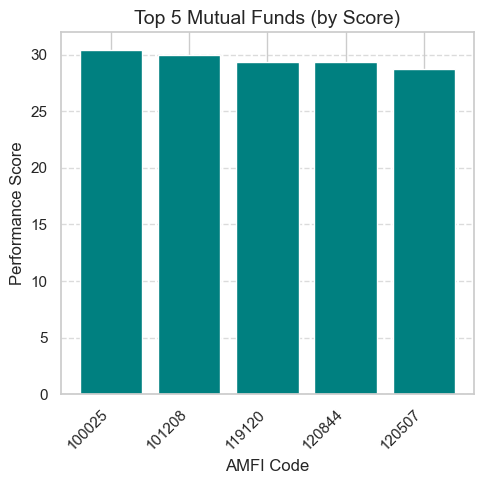

In [46]:
import matplotlib.pyplot as plt
top_5 = final_report.sort_values('Score', ascending=False).head(5)
plt.figure(figsize=(5, 5))
bars = plt.bar(top_5['amfi_code'].astype(str), top_5['Score'], color='teal')
plt.xticks(rotation=45, ha='right')
plt.title('Top 5 Mutual Funds (by Score)', fontsize=14)
plt.xlabel('AMFI Code', fontsize=12)
plt.ylabel('Performance Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Performance_Chart.png')
plt.show()